# Build Phase 1: Case 1

This notebook is a reusable dashboard for Case 1 runs. Change `experiment_config_path` in the first code cell, rerun the setup/config cells, and the artifact tables below will point at that experiment's `outputs/` directory.


In [1]:
from pathlib import Path
import json

from IPython.display import Markdown, display
import pandas as pd
import torch
import yaml

from src.dashboard import (
    available_columns,
    dataset_inventory,
    duplicate_combo_summary,
    headline_scorecard,
    headline_grid_row,
    format_scorecard_table,
    latest_metrics_by_combo,
    load_metrics,
    load_predictions,
    metadata_by_id,
    slice_retention,
)
from src.data.generate import generate_case1
from src.data.io import read_jsonl, filter_split
from src.metrics import exact_match, token_f1, format_validity, RetentionScores
from src.lanczos import l_lanczos

# Dashboard switchboard: change this path to inspect or run another experiment.
experiment_config_path = Path('configs/case1_rich_2h_grid_lora_r1.yaml')

# Set to an integer for quick smoke evaluation; keep None for full eval.
limit_eval = None

# Use True only when resuming a sweep whose existing metrics have the same eval contract.
resume_existing = False

config = yaml.safe_load(experiment_config_path.read_text())
eval_config = config.get('evaluation', {})

config_summary = {
    'experiment_config_path': str(experiment_config_path),
    'data_generator': config['data'].get('generator', 'rule_transform'),
    'model': config['model']['name'],
    'task_a_path': config['data']['task_a_path'],
    'task_b_path': config['data']['task_b_path'],
    'n_per_split': config['data']['n_per_split'],
    'ewc_n0_values': config['ewc']['n0_values'],
    'ewc_rank_values': config['ewc']['rank_values'],
    'ewc_lambda_values': config['ewc']['lambda_values'],
    'eval_batch_size': eval_config.get('batch_size', 1),
    'eval_max_new_tokens': eval_config.get('max_new_tokens', 32),
    'limit_eval': limit_eval,
    'metrics_path': config['outputs']['metrics_path'],
    'run_dir': config['outputs']['run_dir'],
}
config_summary


/home/evan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'experiment_config_path': 'configs/case1_rich_2h_grid.yaml',
 'data_generator': 'rule_transform_v2',
 'model': 'microsoft/Phi-4-mini-instruct',
 'task_a_path': 'data/generated/case1_rich_task_a.jsonl',
 'task_b_path': 'data/generated/case1_rich_task_b.jsonl',
 'n_per_split': 128,
 'ewc_n0_values': [0, 16, 64, 128],
 'ewc_rank_values': [0, 2, 4],
 'ewc_lambda_values': [0.0, 1.0, 10.0],
 'eval_batch_size': 2,
 'eval_max_new_tokens': 12,
 'limit_eval': None,
 'metrics_path': 'outputs/case1_rich_2h_grid/metrics.jsonl',
 'run_dir': 'outputs/case1_rich_2h_grid'}

## Experiment Config

This is the active experiment config. The kickoff command and artifact readers below use the same path, so changing the first cell swaps the notebook to another run.


In [2]:
print(experiment_config_path.read_text())


model:
  name: microsoft/Phi-4-mini-instruct
  cache_dir: data/models
  load_in_4bit: true
  gradient_checkpointing: true
  attn_implementation: flash_attention_2
  trust_remote_code: false

data:
  generator: rule_transform_v2
  generated_dir: data/generated
  task_a_path: data/generated/case1_rich_task_a.jsonl
  task_b_path: data/generated/case1_rich_task_b.jsonl
  original_eval_path: data/generated/eval_original.jsonl
  n_per_split: 128
  seed: 13

training:
  max_seq_length: 512
  per_device_batch_size: 1
  gradient_accumulation_steps: 8
  learning_rate: 0.0002
  epochs: 2
  qlora_rank: 8
  qlora_alpha: 16
  qlora_dropout: 0.05

evaluation:
  batch_size: 2
  max_new_tokens: 12

ewc:
  n0_values: [0, 16, 64, 128]
  rank_values: [0, 2, 4]
  lambda_values: [0.0, 1.0, 10.0]
  combinations:
    - {n0: 0, rank: 0, lambda: 0.0}
    - {n0: 16, rank: 0, lambda: 1.0}
    - {n0: 16, rank: 0, lambda: 10.0}
    - {n0: 16, rank: 2, lambda: 1.0}
    - {n0: 16, rank: 2, lambda: 10.0}
    - {n0: 16

In [3]:
parts = [
    '~/.venv/bin/python -m src.run_case1',
    f'--config {experiment_config_path}',
]
if limit_eval is not None:
    parts.append(f'--limit-eval {limit_eval}')
if resume_existing:
    parts.append('--resume')

kickoff_command = ' '.join(parts)
print(kickoff_command)


~/.venv/bin/python -m src.run_case1 --config configs/case1_rich_2h_grid.yaml


## Generate Synthetic Data

This rewrites deterministic generated data using the active config's `seed`, `n_per_split`, and `data.generator`. The inventory cell below shows split counts and rich metadata distributions when available.


In [4]:
generate_case1(
    output_dir=Path(config['data']['generated_dir']),
    seed=config['data']['seed'],
    n_per_split=config['data']['n_per_split'],
    generator=config['data'].get('generator', 'rule_transform'),
)

task_a = read_jsonl(config['data']['task_a_path'])
task_b = read_jsonl(config['data']['task_b_path'])
len(task_a), len(task_b)


(512, 512)

In [5]:
task_a_inventory = dataset_inventory(task_a)
task_b_inventory = dataset_inventory(task_b)

print('Task A split counts')
display(task_a_inventory['split'].value_counts().rename_axis('split').reset_index(name='n'))
print('Task B split counts')
display(task_b_inventory['split'].value_counts().rename_axis('split').reset_index(name='n'))

for column in ['relation_to_next_task', 'frequency_bucket', 'composition_type']:
    if column in task_a_inventory.columns and task_a_inventory[column].notna().any():
        print(f'\nTask A by split and {column}')
        display(pd.crosstab(task_a_inventory['split'], task_a_inventory[column]))

print('\nExample records')
for example in task_a[:3]:
    print(json.dumps(example.__dict__, indent=2))


Task A split counts


,split,n
0,ewc_init,128
1,train,128
2,eval_seen,128
3,eval_heldout,128


Task B split counts


,split,n
0,ewc_init,128
1,train,128
2,eval_seen,128
3,eval_heldout,128



Task A by split and relation_to_next_task


...


Task A by split and frequency_bucket


frequency_bucket,common,medium,rare
split,,,
eval_heldout,52,51,25
eval_seen,64,32,32
ewc_init,80,32,16
train,80,32,16



Task A by split and composition_type


composition_type,heldout_triple,seen
split,,
eval_heldout,25,103
eval_seen,0,128
ewc_init,0,128
train,0,128



Example records
{
  "id": "task_a_ewc_init_000000",
  "task_family": "rule_transform_v2",
  "task_id": "task_a",
  "split": "ewc_init",
  "prompt": "Routing transform v2: Convert product code GH-33 with priority LOW, region NORTH, and mode STANDARD to its route label. Answer with only the route label.",
  "target": "ROUTE_GREEN_33",
  "answer_key": "ROUTE_GREEN_33",
  "metadata": {
    "composition_type": "seen",
    "entity_id": "GH-33",
    "frequency_bucket": "common",
    "mode": "STANDARD",
    "prefix": "GH",
    "priority": "LOW",
    "region": "NORTH",
    "relation_to_next_task": "shared",
    "requires_reasoning": false,
    "rule_id": "route_GH_LOW_NORTH_STANDARD",
    "validator": {
      "pattern": "ROUTE_[A-Z]+_[0-9]{2}",
      "type": "regex"
    }
  }
}
{
  "id": "task_a_ewc_init_000001",
  "task_family": "rule_transform_v2",
  "task_id": "task_a",
  "split": "ewc_init",
  "prompt": "Routing transform v2: Convert product code GH-45 with priority MEDIUM, region SOUTH, a

## Metric Smoke Checks

In [6]:
print('exact_match:', exact_match(' ROUTE_RED_01 ', 'route_red_01'))
print('token_f1:', token_f1('alpha beta gamma', 'alpha gamma delta'))
print('format_validity:', format_validity('ROUTE_RED_01', {'type': 'regex', 'pattern': r'ROUTE_[A-Z]+_[0-9]{2}'}))

retention = RetentionScores(score_before=0.8, score_after=0.6)
print('forgetting_delta:', retention.forgetting_delta)
print('retention_ratio:', retention.retention_ratio)

exact_match: 1.0
token_f1: 0.6666666666666666
format_validity: 1.0
forgetting_delta: 0.20000000000000007
retention_ratio: 0.7499999999999999


## Lanczos Smoke Check

In [7]:
grads = [torch.tensor([1.0, 0.0]), torch.tensor([0.0, 2.0])]

def get_grad_generator():
    return lambda: iter(grads)

L, diagonal = l_lanczos(
    get_grad_generator=get_grad_generator,
    r=2,
    p=2,
    calc_diag=True,
    disable_tqdm=True,
)
L.shape, diagonal.shape, torch.isfinite(L).all().item(), torch.isfinite(diagonal).all().item()

(torch.Size([2, 2]), torch.Size([2, 1]), True, True)

## Optional: Build Original-Model Retention Set

This downloads and runs `microsoft/Phi-4-mini-instruct`. Run after dependencies are installed and the GPU is available.

In [8]:
# from src.modeling import ModelConfig, load_base_model, load_tokenizer
# from src.original_retention import build_original_retention_set

# tokenizer = load_tokenizer(config['model']['name'], config['model']['cache_dir'])
# model = load_base_model(ModelConfig(**config['model']))
# records = build_original_retention_set(model, tokenizer, Path(config['data']['original_eval_path']), repeats=3)
# len(records)

## Run Active Case 1 Experiment

This is GPU-heavy. It executes every configured EWC combination from the active config, writes metrics and prediction artifacts to that config's output directory, and honors `resume_existing`.


In [9]:
import json
from pathlib import Path

from src.run_case1 import completed_keys, configured_ewc_combinations, run_single

experiment_combinations = configured_ewc_combinations(config)
completed = completed_keys(config['outputs']['metrics_path']) if resume_existing else set()
records = []

print(f'Configured combinations: {len(experiment_combinations)}')
print(f'Resume existing: {resume_existing}')
print(f'Already completed: {len(completed)}')
print(f'Output metrics: {config["outputs"]["metrics_path"]}')

for combo_index, (ewc_n0, ewc_rank, ewc_lambda) in enumerate(experiment_combinations, start=1):
    key = (int(ewc_n0), int(ewc_rank), float(ewc_lambda))
    if key in completed:
        print(json.dumps({'skipped_existing': True, 'combo_index': combo_index, 'ewc_n0': key[0], 'ewc_rank': key[1], 'ewc_lambda': key[2]}))
        continue

    print(f'\nRunning combo {combo_index}/{len(experiment_combinations)}: n0={ewc_n0}, rank={ewc_rank}, lambda={ewc_lambda}')
    record = run_single(
        config=config,
        ewc_n0=int(ewc_n0),
        ewc_rank=int(ewc_rank),
        ewc_lambda=float(ewc_lambda),
        limit_eval=limit_eval,
    )
    records.append(record)
    print(json.dumps(record, sort_keys=True))

print(f'Finished new runs: {len(records)}')
records


Configured combinations: 19
Resume existing: False
Already completed: 0
Output metrics: outputs/case1_rich_2h_grid/metrics.jsonl

Running combo 1/19: n0=0, rank=0, lambda=0.0


This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
Loading weights: 100%|██████████| 194/194 [00:01<00:00, 170.73it/s, Materializing param=model.norm.weight]                              
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/home/evan/.venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer t

{"average_retention": 0.3125, "case": "case1", "data_generator": "rule_transform_v2", "er_buffer": 0, "eval_batch_size": 2, "eval_max_new_tokens": 12, "eval_original_em": 0.125, "ewc_effective_rank": 0, "ewc_lambda": 0.0, "ewc_n0": 0, "ewc_rank": 0, "fisher_wall_seconds": 0.0024566650390625, "forgetting_delta": 0.3984375, "peak_vram_mb": 7189.54638671875, "qlora_rank": 8, "retention_ratio": 0.5, "run_wall_seconds": 241.67202925682068, "target_em": 0.8046875, "target_format_validity": 1.0, "target_token_f1": 0.8046875, "task_a_after_em": 0.3984375, "task_a_before_em": 0.796875, "task_a_composition_heldout_pair_after_em": null, "task_a_composition_heldout_pair_before_em": null, "task_a_composition_heldout_pair_n": 0, "task_a_composition_heldout_triple_after_em": 0.0, "task_a_composition_heldout_triple_before_em": 0.0, "task_a_composition_heldout_triple_n": 25, "task_a_composition_seen_after_em": 0.49514563106796117, "task_a_composition_seen_before_em": 0.9902912621359223, "task_a_composi

Loading weights: 100%|██████████| 194/194 [00:01<00:00, 168.01it/s, Materializing param=model.norm.weight]                              


{"average_retention": 0.3100728155339806, "case": "case1", "data_generator": "rule_transform_v2", "er_buffer": 0, "eval_batch_size": 2, "eval_max_new_tokens": 12, "eval_original_em": 0.125, "ewc_effective_rank": 0, "ewc_lambda": 1.0, "ewc_n0": 16, "ewc_rank": 0, "fisher_wall_seconds": 3.320629596710205, "forgetting_delta": 0.40625, "peak_vram_mb": 7206.67138671875, "qlora_rank": 8, "retention_ratio": 0.49514563106796117, "run_wall_seconds": 247.77572107315063, "target_em": 0.8046875, "target_format_validity": 1.0, "target_token_f1": 0.8046875, "task_a_after_em": 0.3984375, "task_a_before_em": 0.8046875, "task_a_composition_heldout_pair_after_em": null, "task_a_composition_heldout_pair_before_em": null, "task_a_composition_heldout_pair_n": 0, "task_a_composition_heldout_triple_after_em": 0.0, "task_a_composition_heldout_triple_before_em": 0.0, "task_a_composition_heldout_triple_n": 25, "task_a_composition_seen_after_em": 0.49514563106796117, "task_a_composition_seen_before_em": 1.0, "ta

...

Loading weights: 100%|██████████| 194/194 [00:01<00:00, 171.64it/s, Materializing param=model.norm.weight]                              


{"average_retention": 0.3100728155339806, "case": "case1", "data_generator": "rule_transform_v2", "er_buffer": 0, "eval_batch_size": 2, "eval_max_new_tokens": 12, "eval_original_em": 0.125, "ewc_effective_rank": 4, "ewc_lambda": 1.0, "ewc_n0": 128, "ewc_rank": 4, "fisher_wall_seconds": 128.88289642333984, "forgetting_delta": 0.40625, "peak_vram_mb": 7206.67138671875, "qlora_rank": 8, "retention_ratio": 0.49514563106796117, "run_wall_seconds": 366.7113173007965, "target_em": 0.8046875, "target_format_validity": 1.0, "target_token_f1": 0.8046875, "task_a_after_em": 0.3984375, "task_a_before_em": 0.8046875, "task_a_composition_heldout_pair_after_em": null, "task_a_composition_heldout_pair_before_em": null, "task_a_composition_heldout_pair_n": 0, "task_a_composition_heldout_triple_after_em": 0.0, "task_a_composition_heldout_triple_before_em": 0.0, "task_a_composition_heldout_triple_n": 25, "task_a_composition_seen_after_em": 0.49514563106796117, "task_a_composition_seen_before_em": 1.0, "t

Loading weights: 100%|██████████| 194/194 [00:01<00:00, 173.14it/s, Materializing param=model.norm.weight]                              


{"average_retention": 0.3125, "case": "case1", "data_generator": "rule_transform_v2", "er_buffer": 0, "eval_batch_size": 2, "eval_max_new_tokens": 12, "eval_original_em": 0.125, "ewc_effective_rank": 4, "ewc_lambda": 10.0, "ewc_n0": 128, "ewc_rank": 4, "fisher_wall_seconds": 128.78954768180847, "forgetting_delta": 0.3984375, "peak_vram_mb": 7206.67138671875, "qlora_rank": 8, "retention_ratio": 0.5, "run_wall_seconds": 366.52198362350464, "target_em": 0.8046875, "target_format_validity": 1.0, "target_token_f1": 0.8046875, "task_a_after_em": 0.3984375, "task_a_before_em": 0.796875, "task_a_composition_heldout_pair_after_em": null, "task_a_composition_heldout_pair_before_em": null, "task_a_composition_heldout_pair_n": 0, "task_a_composition_heldout_triple_after_em": 0.0, "task_a_composition_heldout_triple_before_em": 0.0, "task_a_composition_heldout_triple_n": 25, "task_a_composition_seen_after_em": 0.49514563106796117, "task_a_composition_seen_before_em": 0.9902912621359223, "task_a_comp

[{'case': 'case1',
  'data_generator': 'rule_transform_v2',
  'train_n': 128,
  'ewc_n0': 0,
  'er_buffer': 0,
  'qlora_rank': 8,
  'ewc_rank': 0,
  'ewc_effective_rank': 0,
  'ewc_lambda': 0.0,
  'eval_batch_size': 2,
  'eval_max_new_tokens': 12,
  'target_em': 0.8046875,
  'target_token_f1': 0.8046875,
  'target_format_validity': 1.0,
  'task_a_before_em': 0.796875,
  'task_a_after_em': 0.3984375,
  'task_a_conflicting_n': 26,
  'task_a_nonconflicting_n': 102,
  'task_a_conflicting_before_em': 1.0,
  'task_a_conflicting_after_em': 0.0,
  'task_a_nonconflicting_before_em': 0.7450980392156863,
  'task_a_nonconflicting_after_em': 0.5,
  'task_a_shared_n': 26,
  'task_a_direct_conflict_n': 26,
  'task_a_near_conflict_n': 26,
  'task_a_rare_rule_n': 25,
  'task_a_heldout_composition_n': 25,
  'task_a_shared_before_em': 1.0,
  'task_a_direct_conflict_before_em': 1.0,
  'task_a_near_conflict_before_em': 1.0,
  'task_a_rare_rule_before_em': 0.96,
  'task_a_heldout_composition_before_em': 0.0

## Experiment Artifacts

The cells below read the saved JSONL artifacts from the active config. Metrics come from `metrics.jsonl`; per-example predictions come from `predictions_*.jsonl` in the active run directory.


In [10]:
from pathlib import Path

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 240)

metrics_path = Path(config['outputs']['metrics_path'])
run_dir = Path(config['outputs']['run_dir'])

if not metrics_path.exists():
    raise FileNotFoundError(f'No metrics found at {metrics_path}. Run the kickoff command above first.')

df = load_metrics(metrics_path)
df_latest = latest_metrics_by_combo(df)
duplicate_combos = duplicate_combo_summary(df)

score_cols = [
    'run_index',
    'is_latest_for_combo',
    'combo_run_count',
    'data_generator',
    'ewc_n0',
    'ewc_rank',
    'ewc_effective_rank',
    'ewc_lambda',
    'eval_batch_size',
    'eval_max_new_tokens',
    'target_em',
    'task_a_before_em',
    'task_a_after_em',
    'task_a_shared_after_em',
    'task_a_direct_conflict_after_em',
    'task_a_near_conflict_after_em',
    'task_a_rare_rule_after_em',
    'task_a_heldout_composition_after_em',
    'task_a_conflicting_after_em',
    'task_a_nonconflicting_after_em',
    'forgetting_delta',
    'retention_ratio',
    'eval_original_em',
    'average_retention',
    'worst_task_retention',
    'peak_vram_mb',
    'fisher_wall_seconds',
    'run_wall_seconds',
]

if not duplicate_combos.empty:
    display(Markdown('**Duplicate combo rows detected.** Pivots and plots below use only the latest row per `(ewc_n0, ewc_rank, ewc_lambda)` combo.'))
    display(duplicate_combos)

print('All metric rows')
display(df[available_columns(df, score_cols)])

print('Latest metric row per combo')
display(df_latest[available_columns(df_latest, score_cols)])


All metric rows


,run_index,is_latest_for_combo,combo_run_count,data_generator,ewc_n0,ewc_rank,ewc_effective_rank,ewc_lambda,eval_batch_size,eval_max_new_tokens,target_em,task_a_before_em,task_a_after_em,task_a_shared_after_em,task_a_direct_conflict_after_em,task_a_near_conflict_after_em,task_a_rare_rule_after_em,task_a_heldout_composition_after_em,task_a_conflicting_after_em,task_a_nonconflicting_after_em,forgetting_delta,retention_ratio,eval_original_em,average_retention,worst_task_retention,peak_vram_mb,fisher_wall_seconds,run_wall_seconds
0,0,True,1,rule_transform_v2,0,0,0,0.0,2,12,0.804688,0.796875,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.398438,0.500000,0.125,0.312500,0.125,7189.546387,0.002457,241.672029
1,1,True,1,rule_transform_v2,16,0,0,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,3.320630,247.775721
2,2,True,1,rule_transform_v2,16,0,0,10.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.000,0.247573,0.000,7206.671387,3.325467,247.596654
3,3,True,1,rule_transform_v2,16,2,2,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.000,0.247573,0.000,7206.671387,9.939160,254.424277
4,4,True,1,rule_transform_v2,16,2,2,10.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,9.985362,255.225766
5,5,True,1,rule_transform_v2,16,4,4,1.0,2,12,0.804688,0.781250,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.382812,0.510000,0.125,0.317500,0.125,7206.671387,16.487294,260.545488
6,6,True,1,rule_transform_v2,16,4,4,10.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,16.628633,260.513575
7,7,True,1,rule_transform_v2,64,0,0,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,13.204314,256.689775
8,8,True,1,rule_transform_v2,64,0,0,10.0,2,12,0.804688,0.757812,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.359375,0.525773,0.125,0.325387,0.125,7206.671387,12.936872,253.005266
9,9,True,1,rule_transform_v2,64,2,2,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,38.634560,276.146121


Latest metric row per combo


,run_index,is_latest_for_combo,combo_run_count,data_generator,ewc_n0,ewc_rank,ewc_effective_rank,ewc_lambda,eval_batch_size,eval_max_new_tokens,target_em,task_a_before_em,task_a_after_em,task_a_shared_after_em,task_a_direct_conflict_after_em,task_a_near_conflict_after_em,task_a_rare_rule_after_em,task_a_heldout_composition_after_em,task_a_conflicting_after_em,task_a_nonconflicting_after_em,forgetting_delta,retention_ratio,eval_original_em,average_retention,worst_task_retention,peak_vram_mb,fisher_wall_seconds,run_wall_seconds
0,0,True,1,rule_transform_v2,0,0,0,0.0,2,12,0.804688,0.796875,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.398438,0.500000,0.125,0.312500,0.125,7189.546387,0.002457,241.672029
1,1,True,1,rule_transform_v2,16,0,0,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,3.320630,247.775721
2,2,True,1,rule_transform_v2,16,0,0,10.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.000,0.247573,0.000,7206.671387,3.325467,247.596654
3,3,True,1,rule_transform_v2,16,2,2,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.000,0.247573,0.000,7206.671387,9.939160,254.424277
4,4,True,1,rule_transform_v2,16,2,2,10.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,9.985362,255.225766
5,5,True,1,rule_transform_v2,16,4,4,1.0,2,12,0.804688,0.781250,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.382812,0.510000,0.125,0.317500,0.125,7206.671387,16.487294,260.545488
6,6,True,1,rule_transform_v2,16,4,4,10.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,16.628633,260.513575
7,7,True,1,rule_transform_v2,64,0,0,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,13.204314,256.689775
8,8,True,1,rule_transform_v2,64,0,0,10.0,2,12,0.804688,0.757812,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.359375,0.525773,0.125,0.325387,0.125,7206.671387,12.936872,253.005266
9,9,True,1,rule_transform_v2,64,2,2,1.0,2,12,0.804688,0.804688,0.398438,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.406250,0.495146,0.125,0.310073,0.125,7206.671387,38.634560,276.146121


### Grid Scorecard

One row per latest hyperparameter combo. This is the main table to scan for grid experiments; detailed slice tables below explain why a row scored the way it did.


In [11]:
task_a_examples = read_jsonl(config['data']['task_a_path'])
task_b_examples = read_jsonl(config['data']['task_b_path'])
task_a_metadata_by_id = metadata_by_id(task_a_examples)
task_b_metadata_by_id = metadata_by_id(task_b_examples)

scorecard_rows = []
scorecard_missing_artifacts = []
for metric_row in df_latest.itertuples(index=False):
    metric_series = pd.Series(metric_row._asdict())
    try:
        task_a_before_for_row = load_predictions(
            run_dir,
            'task_a_before',
            ewc_n0=int(metric_series['ewc_n0']),
            ewc_rank=int(metric_series['ewc_rank']),
            ewc_lambda=float(metric_series['ewc_lambda']),
            metadata_by_id=task_a_metadata_by_id,
        )
        task_a_after_for_row = load_predictions(
            run_dir,
            'task_a_after',
            ewc_n0=int(metric_series['ewc_n0']),
            ewc_rank=int(metric_series['ewc_rank']),
            ewc_lambda=float(metric_series['ewc_lambda']),
            metadata_by_id=task_a_metadata_by_id,
        )
        task_b_after_for_row = load_predictions(
            run_dir,
            'task_b_after',
            ewc_n0=int(metric_series['ewc_n0']),
            ewc_rank=int(metric_series['ewc_rank']),
            ewc_lambda=float(metric_series['ewc_lambda']),
            metadata_by_id=task_b_metadata_by_id,
        )
    except FileNotFoundError as exc:
        scorecard_missing_artifacts.append(str(exc))
        task_a_before_for_row = task_a_after_for_row = task_b_after_for_row = None
    scorecard_rows.append(headline_grid_row(metric_series, task_a_before_for_row, task_a_after_for_row, task_b_after_for_row))

scorecard = pd.DataFrame(scorecard_rows)
scorecard_cols = [
    'run_index',
    'ewc_n0',
    'ewc_rank',
    'ewc_lambda',
    'target_seen_em',
    'target_heldout_composition_em',
    'protected_retention_em',
    'protected_retention_drop',
    'near_conflict_retention_em',
    'expected_overwrite_em',
    'base_retention_em',
    'run_wall_seconds',
    'peak_vram_mb',
    'target_seen_n',
    'target_heldout_composition_n',
    'protected_retention_n',
    'near_conflict_n',
    'expected_overwrite_n',
]
if scorecard_missing_artifacts:
    display(Markdown('**Some prediction artifacts were missing.** Scorecard columns derived from predictions are blank for those rows.'))
    for missing in scorecard_missing_artifacts:
        print(missing)

display(format_scorecard_table(scorecard[available_columns(scorecard, scorecard_cols)]))


,run_index,ewc_n0,ewc_rank,ewc_lambda,target_seen_em,target_heldout_composition_em,protected_retention_em,protected_retention_drop,near_conflict_retention_em,expected_overwrite_em,base_retention_em,run_wall_seconds,peak_vram_mb,target_seen_n,target_heldout_composition_n,protected_retention_n,near_conflict_n,expected_overwrite_n
0,0,0,0,0,1.000,0.000,0.662,0.325,0.000,1.000,0.125,241.7,7190,103,25,77,26,26
1,1,16,0,1,1.000,0.000,0.662,0.338,0.000,1.000,0.125,247.8,7207,103,25,77,26,26
2,2,16,0,10,1.000,0.000,0.662,0.338,0.000,1.000,0.000,247.6,7207,103,25,77,26,26
3,3,16,2,1,1.000,0.000,0.662,0.338,0.000,1.000,0.000,254.4,7207,103,25,77,26,26
4,4,16,2,10,1.000,0.000,0.662,0.338,0.000,1.000,0.125,255.2,7207,103,25,77,26,26
5,5,16,4,1,1.000,0.000,0.662,0.299,0.000,1.000,0.125,260.5,7207,103,25,77,26,26
6,6,16,4,10,1.000,0.000,0.662,0.338,0.000,1.000,0.125,260.5,7207,103,25,77,26,26
7,7,64,0,1,1.000,0.000,0.662,0.338,0.000,1.000,0.125,256.7,7207,103,25,77,26,26
8,8,64,0,10,1.000,0.000,0.662,0.260,0.000,1.000,0.125,253.0,7207,103,25,77,26,26
9,9,64,2,1,1.000,0.000,0.662,0.338,0.000,1.000,0.125,276.1,7207,103,25,77,26,26


### Rich Retention Slices

For `rule_transform_v2`, this compares Task A predictions before and after Task B by `relation_to_next_task`, `frequency_bucket`, and `composition_type`. Older runs without rich metadata still show the derived legacy conflict grouping.


In [12]:
slice_keys = ['relation_to_next_task', 'frequency_bucket', 'composition_type', 'legacy_conflict_group']
retention_rows = []
missing_prediction_artifacts = []

for metric_row in df_latest.itertuples(index=False):
    try:
        before = load_predictions(
            run_dir,
            'task_a_before',
            ewc_n0=int(metric_row.ewc_n0),
            ewc_rank=int(metric_row.ewc_rank),
            ewc_lambda=float(metric_row.ewc_lambda),
            metadata_by_id=task_a_metadata_by_id,
        )
        after = load_predictions(
            run_dir,
            'task_a_after',
            ewc_n0=int(metric_row.ewc_n0),
            ewc_rank=int(metric_row.ewc_rank),
            ewc_lambda=float(metric_row.ewc_lambda),
            metadata_by_id=task_a_metadata_by_id,
        )
    except FileNotFoundError as exc:
        missing_prediction_artifacts.append(str(exc))
        continue

    for key in slice_keys:
        sliced = slice_retention(before, after, key)
        if sliced.empty:
            continue
        sliced.insert(0, 'slice_key', key)
        sliced.insert(0, 'ewc_lambda', float(metric_row.ewc_lambda))
        sliced.insert(0, 'ewc_rank', int(metric_row.ewc_rank))
        sliced.insert(0, 'ewc_n0', int(metric_row.ewc_n0))
        sliced.insert(0, 'run_index', int(metric_row.run_index))
        sliced = sliced.rename(columns={key: 'slice_value'})
        retention_rows.append(sliced)

if missing_prediction_artifacts:
    display(Markdown('**Missing prediction artifacts:**'))
    for missing in missing_prediction_artifacts:
        print(missing)

retention_slices = pd.concat(retention_rows, ignore_index=True) if retention_rows else pd.DataFrame()
retention_cols = ['run_index', 'ewc_n0', 'ewc_rank', 'ewc_lambda', 'slice_key', 'slice_value', 'before_em', 'after_em', 'forgetting_delta', 'before_n', 'after_n', 'n']

if retention_slices.empty:
    display(Markdown('No metadata-sliced prediction artifacts are available for the active config yet.'))
else:
    display(retention_slices[available_columns(retention_slices, retention_cols)])
    for key in slice_keys:
        key_df = retention_slices[retention_slices['slice_key'] == key]
        if not key_df.empty:
            print(f'\nTask A after EM by {key}')
            display(key_df.pivot_table(index=['ewc_n0', 'ewc_rank'], columns='slice_value', values='after_em'))


,run_index,ewc_n0,ewc_rank,ewc_lambda,slice_key,slice_value,before_em,after_em,forgetting_delta,before_n,after_n,n
0,0,0,0,0.0,relation_to_next_task,direct_conflict,1.000000,0.000000,1.000000,26,26,26
1,0,0,0,0.0,relation_to_next_task,heldout_composition,0.000000,0.000000,0.000000,25,25,25
2,0,0,0,0.0,relation_to_next_task,near_conflict,1.000000,0.000000,1.000000,26,26,26
3,0,0,0,0.0,relation_to_next_task,rare_rule,0.960000,1.000000,-0.040000,25,25,25
4,0,0,0,0.0,relation_to_next_task,shared,1.000000,1.000000,0.000000,26,26,26
...,...,...,...,...,...,...,...,...,...,...,...,...
223,18,128,4,10.0,frequency_bucket,rare,1.000000,1.000000,0.000000,25,25,25
224,18,128,4,10.0,composition_type,heldout_triple,0.000000,0.000000,0.000000,25,25,25
225,18,128,4,10.0,composition_type,seen,0.990291,0.495146,0.495146,103,103,103
226,18,128,4,10.0,legacy_conflict_group,conflicting,0.987013,0.324675,0.662338,77,77,77



Task A after EM by relation_to_next_task


slice_value      direct_conflict  heldout_composition  near_conflict  rare_rule  shared
ewc_n0 ewc_rank                                                                        
0      0                     0.0                  0.0            0.0        1.0     1.0
16     0                     0.0                  0.0            0.0        1.0     1.0
       2                     0.0                  0.0            0.0        1.0     1.0
       4                     0.0                  0.0            0.0        1.0     1.0
64     0                     0.0                  0.0            0.0        1.0     1.0
       2                     0.0                  0.0            0.0        1.0     1.0
       4                     0.0                  0.0            0.0        1.0     1.0
128    0                     0.0                  0.0            0.0        1.0     1.0
       2                     0.0                  0.0            0.0        1.0     1.0
       4                     0.0                  0.0            0.0        1.0     1.0


Task A after EM by frequency_bucket


slice_value      common  medium  rare
ewc_n0 ewc_rank                      
0      0            0.5     0.0   1.0
16     0            0.5     0.0   1.0
       2            0.5     0.0   1.0
       4            0.5     0.0   1.0
64     0            0.5     0.0   1.0
       2            0.5     0.0   1.0
       4            0.5     0.0   1.0
128    0            0.5     0.0   1.0
       2            0.5     0.0   1.0
       4            0.5     0.0   1.0


Task A after EM by composition_type


slice_value      heldout_triple      seen
ewc_n0 ewc_rank                          
0      0                    0.0  0.495146
16     0                    0.0  0.495146
       2                    0.0  0.495146
       4                    0.0  0.495146
64     0                    0.0  0.495146
       2                    0.0  0.495146
       4                    0.0  0.495146
128    0                    0.0  0.495146
       2                    0.0  0.495146
       4                    0.0  0.495146


Task A after EM by legacy_conflict_group


slice_value      conflicting  nonconflicting
ewc_n0 ewc_rank                             
0      0            0.324675        0.509804
16     0            0.324675        0.509804
       2            0.324675        0.509804
       4            0.324675        0.509804
64     0            0.324675        0.509804
       2            0.324675        0.509804
       4            0.324675        0.509804
128    0            0.324675        0.509804
       2            0.324675        0.509804
       4            0.324675        0.509804

In [13]:
selected_row = df_latest.iloc[-1]
latest_task_a_after = load_predictions(
    run_dir,
    'task_a_after',
    ewc_n0=int(selected_row['ewc_n0']),
    ewc_rank=int(selected_row['ewc_rank']),
    ewc_lambda=float(selected_row['ewc_lambda']),
    metadata_by_id=task_a_metadata_by_id,
)
preview_cols = [
    'id',
    'rule_id',
    'relation_to_next_task',
    'frequency_bucket',
    'composition_type',
    'legacy_conflict_group',
    'target',
    'parsed_prediction',
    'exact_match',
]
display(latest_task_a_after[available_columns(latest_task_a_after, preview_cols)])


,id,rule_id,relation_to_next_task,frequency_bucket,composition_type,legacy_conflict_group,target,parsed_prediction,exact_match
0,task_a_eval_heldout_000000,route_CD_MEDIUM_NORTH_BULK,shared,common,seen,nonconflicting,ROUTE_GREEN_22,ROUTE_GREEN_22,1.0
1,task_a_eval_heldout_000001,route_AB_HIGH_SOUTH_STANDARD,direct_conflict,common,seen,conflicting,ROUTE_BLUE_03,ROUTE_RED_03,0.0
2,task_a_eval_heldout_000002,route_EF_LOW_SOUTH_STANDARD,near_conflict,medium,seen,conflicting,ROUTE_BLUE_26,ROUTE_RED_26,0.0
3,task_a_eval_heldout_000003,route_JK_MEDIUM_EAST_LEGACY,rare_rule,rare,seen,conflicting,ROUTE_PURPLE_94,ROUTE_PURPLE_94,1.0
4,task_a_eval_heldout_000004,route_LM_HIGH_WEST_NIGHT,heldout_composition,medium,heldout_triple,nonconflicting,ROUTE_CYAN_41,ROUTE_RED_41,0.0
...,...,...,...,...,...,...,...,...,...
123,task_a_eval_heldout_000123,route_JK_MEDIUM_EAST_LEGACY,rare_rule,rare,seen,conflicting,ROUTE_PURPLE_78,ROUTE_PURPLE_78,1.0
124,task_a_eval_heldout_000124,route_LM_HIGH_WEST_NIGHT,heldout_composition,medium,heldout_triple,nonconflicting,ROUTE_CYAN_83,ROUTE_RED_83,0.0
125,task_a_eval_heldout_000125,route_GH_LOW_SOUTH_STANDARD,shared,common,seen,nonconflicting,ROUTE_GREEN_81,ROUTE_GREEN_81,1.0
126,task_a_eval_heldout_000126,route_AB_HIGH_SOUTH_STANDARD,direct_conflict,common,seen,conflicting,ROUTE_BLUE_18,ROUTE_RED_18,0.0


### Metrics Pivots

These pivots use the latest row per hyperparameter combo, so repeated smoke runs do not double-count a setting.


In [14]:
pivot_metrics = [
    'target_em',
    'task_a_before_em',
    'task_a_after_em',
    'task_a_shared_after_em',
    'task_a_direct_conflict_after_em',
    'task_a_near_conflict_after_em',
    'task_a_rare_rule_after_em',
    'task_a_heldout_composition_after_em',
    'task_a_conflicting_after_em',
    'task_a_nonconflicting_after_em',
    'forgetting_delta',
    'retention_ratio',
    'eval_original_em',
    'fisher_wall_seconds',
    'run_wall_seconds',
]

for metric in [metric for metric in pivot_metrics if metric in df_latest.columns]:
    print(f'\n{metric}')
    display(df_latest.pivot(index='ewc_n0', columns='ewc_rank', values=metric))



target_em


ValueError: Index contains duplicate entries, cannot reshape

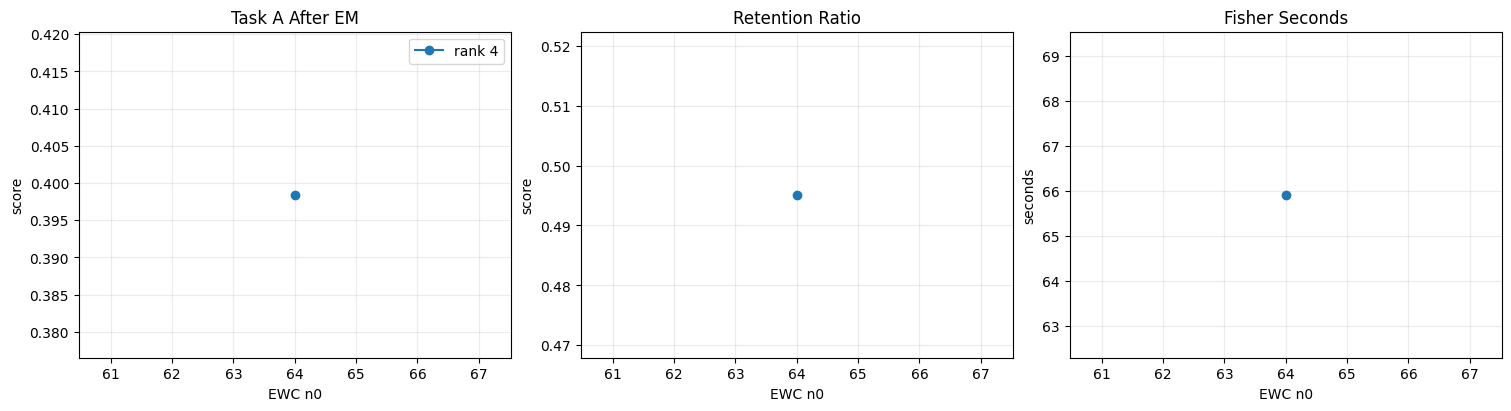

In [ ]:
import matplotlib.pyplot as plt

required_plot_cols = {'ewc_n0', 'ewc_rank', 'task_a_after_em', 'retention_ratio', 'fisher_wall_seconds'}
if required_plot_cols.issubset(df_latest.columns):
    plot_df = df_latest.copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    for rank, group in plot_df.groupby('ewc_rank'):
        group = group.sort_values('ewc_n0')
        axes[0].plot(group['ewc_n0'], group['task_a_after_em'], marker='o', label=f'rank {rank}')
        axes[1].plot(group['ewc_n0'], group['retention_ratio'], marker='o', label=f'rank {rank}')
        axes[2].plot(group['ewc_n0'], group['fisher_wall_seconds'], marker='o', label=f'rank {rank}')

    axes[0].set_title('Task A After EM')
    axes[1].set_title('Retention Ratio')
    axes[2].set_title('Fisher Seconds')
    for ax in axes:
        ax.set_xlabel('EWC n0')
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel('score')
    axes[1].set_ylabel('score')
    axes[2].set_ylabel('seconds')
    axes[0].legend()
    plt.show()
else:
    display(Markdown('Plot skipped because one or more required metric columns are unavailable.'))


In [ ]:
summary_values = {'rows': len(df), 'latest_combo_rows': len(df_latest)}
for output_name, column, reducer in [
    ('best_task_a_after_em', 'task_a_after_em', 'max'),
    ('best_retention_ratio', 'retention_ratio', 'max'),
    ('max_peak_vram_mb', 'peak_vram_mb', 'max'),
    ('max_fisher_wall_seconds', 'fisher_wall_seconds', 'max'),
    ('max_run_wall_seconds', 'run_wall_seconds', 'max'),
]:
    if column in df_latest.columns:
        summary_values[output_name] = getattr(df_latest[column], reducer)()
if 'target_em' in df_latest.columns:
    summary_values['all_target_em_saturated'] = bool((df_latest['target_em'] == 1.0).all())

pd.DataFrame([summary_values])


,rows,latest_combo_rows,best_task_a_after_em,best_retention_ratio,max_peak_vram_mb,max_fisher_wall_seconds,max_run_wall_seconds,all_target_em_saturated
0,2,1,0.398438,0.495146,7170.060059,65.913244,307.807664,False


### Prediction Explorer

The default below inspects the latest metric row in the active experiment. Change the knobs to inspect another combo or split.


In [ ]:
selected_row = df_latest.iloc[-1]

# Change these knobs to inspect another row.
inspect_n0 = int(selected_row['ewc_n0'])
inspect_rank = int(selected_row['ewc_rank'])
inspect_lambda = float(selected_row['ewc_lambda'])
inspect_split = 'task_a_after'

preds = load_predictions(
    run_dir,
    inspect_split,
    ewc_n0=inspect_n0,
    ewc_rank=inspect_rank,
    ewc_lambda=inspect_lambda,
    metadata_by_id=task_a_metadata_by_id,
)

prediction_cols = [
    'id',
    'rule_id',
    'relation_to_next_task',
    'frequency_bucket',
    'composition_type',
    'legacy_conflict_group',
    'target',
    'parsed_prediction',
    'exact_match',
]
display(preds[available_columns(preds, prediction_cols)])


,id,rule_id,relation_to_next_task,frequency_bucket,composition_type,legacy_conflict_group,target,parsed_prediction,exact_match
0,task_a_eval_heldout_000000,route_CD_MEDIUM_NORTH_BULK,shared,common,seen,nonconflicting,ROUTE_GREEN_22,ROUTE_GREEN_22,1.0
1,task_a_eval_heldout_000001,route_AB_HIGH_SOUTH_STANDARD,direct_conflict,common,seen,conflicting,ROUTE_BLUE_03,ROUTE_RED_03,0.0
2,task_a_eval_heldout_000002,route_EF_LOW_SOUTH_STANDARD,near_conflict,medium,seen,conflicting,ROUTE_BLUE_26,ROUTE_RED_26,0.0
3,task_a_eval_heldout_000003,route_JK_MEDIUM_EAST_LEGACY,rare_rule,rare,seen,conflicting,ROUTE_PURPLE_94,ROUTE_PURPLE_94,1.0
4,task_a_eval_heldout_000004,route_LM_HIGH_WEST_NIGHT,heldout_composition,medium,heldout_triple,nonconflicting,ROUTE_CYAN_41,ROUTE_RED_41,0.0
...,...,...,...,...,...,...,...,...,...
123,task_a_eval_heldout_000123,route_JK_MEDIUM_EAST_LEGACY,rare_rule,rare,seen,conflicting,ROUTE_PURPLE_78,ROUTE_PURPLE_78,1.0
124,task_a_eval_heldout_000124,route_LM_HIGH_WEST_NIGHT,heldout_composition,medium,heldout_triple,nonconflicting,ROUTE_CYAN_83,ROUTE_RED_83,0.0
125,task_a_eval_heldout_000125,route_GH_LOW_SOUTH_STANDARD,shared,common,seen,nonconflicting,ROUTE_GREEN_81,ROUTE_GREEN_81,1.0
126,task_a_eval_heldout_000126,route_AB_HIGH_SOUTH_STANDARD,direct_conflict,common,seen,conflicting,ROUTE_BLUE_18,ROUTE_RED_18,0.0


In [ ]:
failure_cols = [
    'prompt',
    'rule_id',
    'relation_to_next_task',
    'frequency_bucket',
    'composition_type',
    'target',
    'parsed_prediction',
    'prediction',
    'exact_match',
]
failures = preds[preds['exact_match'] == 0] if 'exact_match' in preds.columns else pd.DataFrame()
if failures.empty:
    display(Markdown('No exact-match failures in the selected prediction artifact.'))
else:
    display(failures[available_columns(failures, failure_cols)].head(20))


,prompt,rule_id,relation_to_next_task,frequency_bucket,composition_type,target,parsed_prediction,prediction,exact_match
1,Routing transform v2: Convert product code AB-...,route_AB_HIGH_SOUTH_STANDARD,direct_conflict,common,seen,ROUTE_BLUE_03,ROUTE_RED_03,ROUTE_RED_03_RED_03_RED_03_RED,0.0
2,Routing transform v2: Convert product code EF-...,route_EF_LOW_SOUTH_STANDARD,near_conflict,medium,seen,ROUTE_BLUE_26,ROUTE_RED_26,ROUTE_RED_26_LOW_RED_26_RED_26,0.0
4,Routing transform v2: Convert product code LM-...,route_LM_HIGH_WEST_NIGHT,heldout_composition,medium,heldout_triple,ROUTE_CYAN_41,ROUTE_RED_41,ROUTE_RED_41_RED_41_RED_41_RED,0.0
6,Routing transform v2: Convert product code AB-...,route_AB_HIGH_NORTH_STANDARD,direct_conflict,common,seen,ROUTE_BLUE_40,ROUTE_RED_40,ROUTE_RED_40_HIGH_RED_40_RED_40,0.0
7,Routing transform v2: Convert product code EF-...,route_EF_LOW_SOUTH_STANDARD,near_conflict,medium,seen,ROUTE_BLUE_82,ROUTE_RED_82,ROUTE_RED_82_LOW_RED_82_RED_82,0.0
9,Routing transform v2: Convert product code LM-...,route_LM_HIGH_WEST_NIGHT,heldout_composition,medium,heldout_triple,ROUTE_CYAN_59,ROUTE_RED_59,ROUTE_RED_59_HIGH_RED_59_RED_59,0.0
11,Routing transform v2: Convert product code AB-...,route_AB_HIGH_NORTH_STANDARD,direct_conflict,common,seen,ROUTE_BLUE_19,ROUTE_RED_19,ROUTE_RED_19_RED_19_RED_19_RED,0.0
12,Routing transform v2: Convert product code EF-...,route_EF_LOW_SOUTH_STANDARD,near_conflict,medium,seen,ROUTE_BLUE_90,ROUTE_RED_90,ROUTE_RED_90_LOW_RED_90_RED_90,0.0
14,Routing transform v2: Convert product code LM-...,route_LM_HIGH_WEST_NIGHT,heldout_composition,medium,heldout_triple,ROUTE_CYAN_76,ROUTE_RED_76,ROUTE_RED_76_HIGH_RED_76_RED_76,0.0
16,Routing transform v2: Convert product code AB-...,route_AB_LOW_SOUTH_STANDARD,direct_conflict,common,seen,ROUTE_BLUE_29,ROUTE_RED_29,ROUTE_RED_29_LOW_RED_29_RED_29,0.0


### Current Interpretation

Use this section as scratch space for the active experiment's readout. The notebook follows `experiment_config_path`, uses only that config's output paths, and highlights repeated combo rows before showing latest-per-combo pivots.
